# Clifford Volume and Free-Fermion Benchmark
## Cirq demonstration


The following packages are required to run this tutorial:
- `cirq`
- `cirq-google`
- `qsimcirq`

Make sure these packages are installed in your Python environment.

If needed, you can install them with:
```bash
pip install cirq cirq-google qsimcirq
```


In [3]:
from frontier import (
    CliffordVolumeBenchmark,
    FreeFermionVolumeBenchmark,
)

import cirq
from cirq.contrib.qasm_import import circuit_from_qasm

import cirq_google as cg

import qsimcirq

## Create benchmark


In [2]:
# Generate the benchmarks

n_qubits = 5
sample_size = 4
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()


FreeFermion_benchmark = FreeFermionVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)

_ = FreeFermion_benchmark.create_benchmark()

## Simulate circuits


In [3]:
# Convert the QASM strings to Cirq circuits

circuits = Clifford_benchmark.get_all_circuits()  # Get all benchmark circuits
clifford_circuits = [
    circuit_from_qasm(qasm_str) for qasm_str in circuits
]  # Collect the Cirq circuits

# Convert the QASM strings to Cirq circuits

circuits = FreeFermion_benchmark.get_all_circuits()  # Get all benchmark circuits
freefermion_circuits = [
    circuit_from_qasm(qasm_str) for qasm_str in circuits
]  # Collect the Cirq circuits

In [4]:
# Create the ideal simulator

simulator = cirq.Simulator()

In [5]:
# Execute the circuits

clifford_results = simulator.run_batch(
    programs=clifford_circuits,
    params_list=[{} for _ in clifford_circuits],
    repetitions=Clifford_benchmark.shots,
)


freefermion_results = simulator.run_batch(
    programs=freefermion_circuits,
    params_list=[{} for _ in freefermion_circuits],
    repetitions=FreeFermion_benchmark.shots,
)

In [6]:
# Get the counts from the measurement results
clifford_counts = []  # Store the counts for the Clifford Volume benchmark
for result in clifford_results:
    count = result[0].multi_measurement_histogram(
        keys=[f"c_{i}" for i in range(Clifford_benchmark.number_of_qubits)]
    )

    # Convert Cirq-style counts into the default bitstring-based count format
    counts_bitstring = {}
    for k in count.keys():
        bits = "".join([str(bit) for bit in k])

        counts_bitstring[bits] = count[k]

    clifford_counts.append(counts_bitstring)

In [7]:
# Get the counts from the measurement results
freefermion_counts = []  # Store the counts for the Free-Fermion Volume benchmark
for result in freefermion_results:
    count = result[0].multi_measurement_histogram(
        keys=[f"c_{i}" for i in range(FreeFermion_benchmark.number_of_qubits)]
    )

    # Convert Cirq-style counts into the default bitstring-based count format
    counts_bitstring = {}
    for k in count.keys():
        bits = "".join([str(bit) for bit in k])

        counts_bitstring[bits] = count[k]

    freefermion_counts.append(counts_bitstring)

### Attach the simulated results to the benchmark object


In [8]:
Clifford_benchmark.add_experimental_results(
    clifford_counts,
    experiment_id="cirq_clifford_demo",
    platform="cirq",
    experiment_metadata={"backend": "Cirq-simulator"},
)


FreeFermion_benchmark.add_experimental_results(
    freefermion_counts,
    experiment_id="cirq_freefermion_demo",
    platform="cirq",
    experiment_metadata={"backend": "Cirq-simulator"},
)

### Evaluate and plot the benchmark



 Clifford Benchmark Evaluation (5 qubits)
Thresholds: τ_S = 1/e = 0.367879   τ_D = 1/(2e) = 0.183940
Shots per circuit: 1024
--------------------------------------------------------------
Stabilizers (all measured):
  • mean ± std: 1.000000 ± 0.000000
  • min EV:     1.000000
Destabilizers (all measured):
  • mean ± std: 0.006836 ± 0.026601
  • max |EV|:   0.042969
--------------------------------------------------------------
Per-sample pass count: 4/4
Worst stabilizer margin (min over samples of <S>-2σ): sample 0 -> 1.000000
Worst destabilizer margin (max over samples of |<D>|+2σ): sample 2 -> 0.105411
Benchmark passed (all samples): True



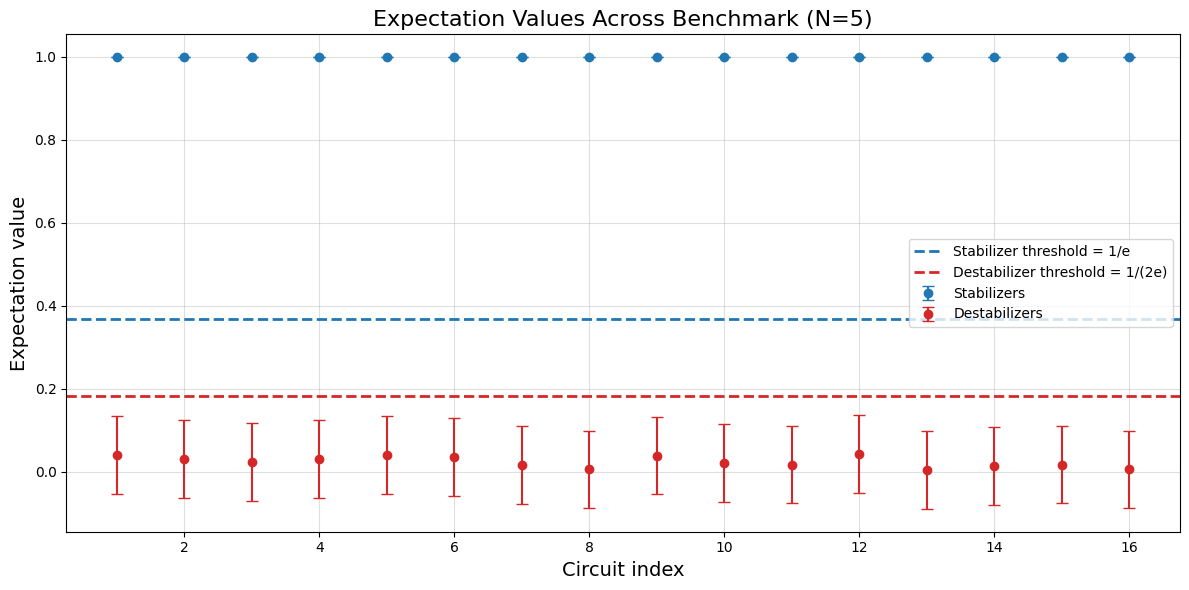

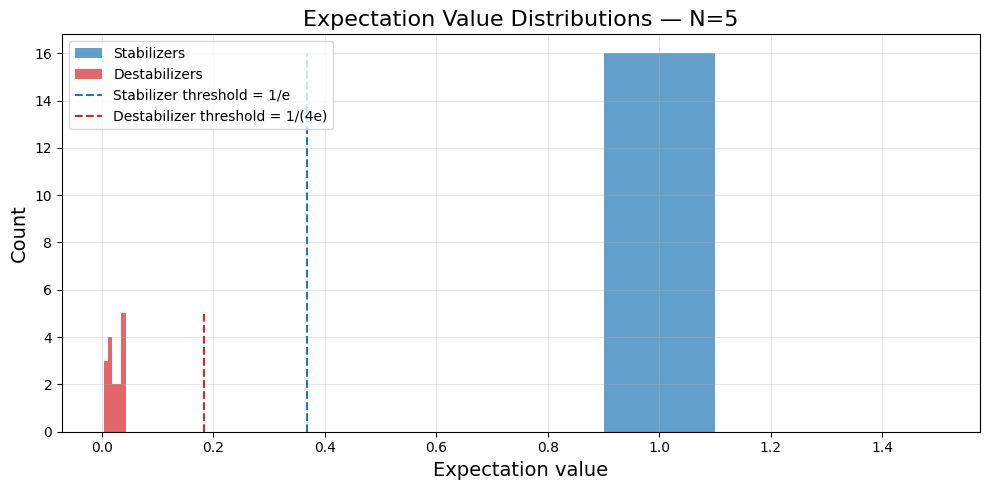

In [9]:
# Clifford Volume
evaluation = Clifford_benchmark.evaluate_benchmark()
Clifford_benchmark.plot_all_expectation_values()
Clifford_benchmark.plot_expectation_histograms(bins=5)


 Free-Fermion Benchmark Evaluation (5 qubits)

Parallel projected values (should be near 1):
  • average: 1.013288 ± 0.013359
  • lowest measured value: 0.999719

Orthogonal projected values (should be near 0):
  • average: 0.000913 ± 0.015100
  • highest absolute value: 0.025889


Benchmark passed: True



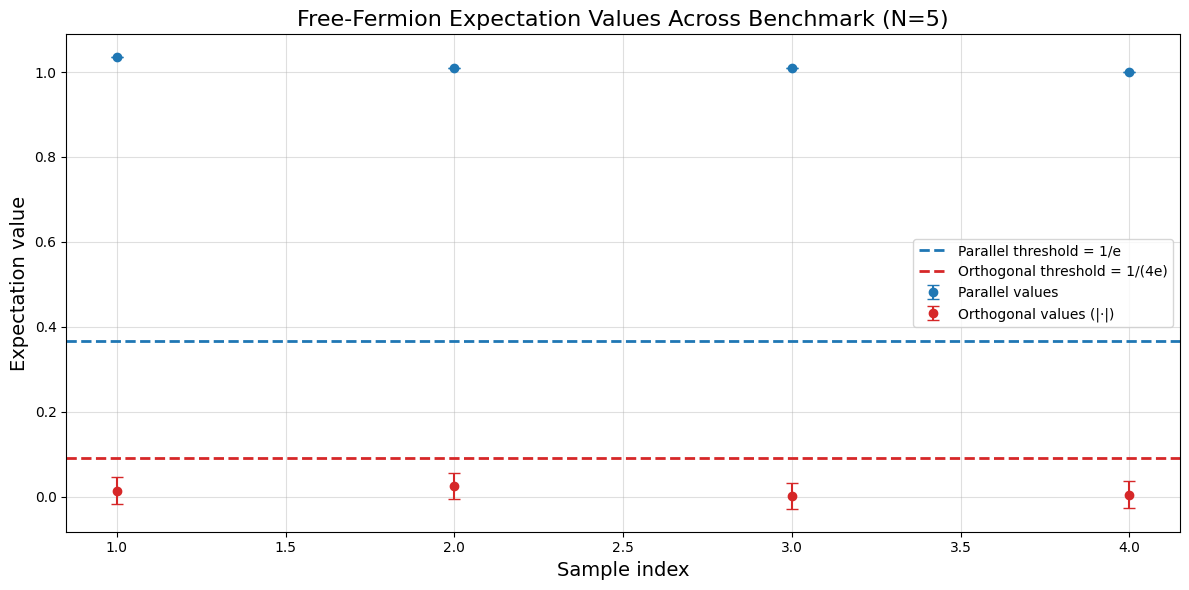

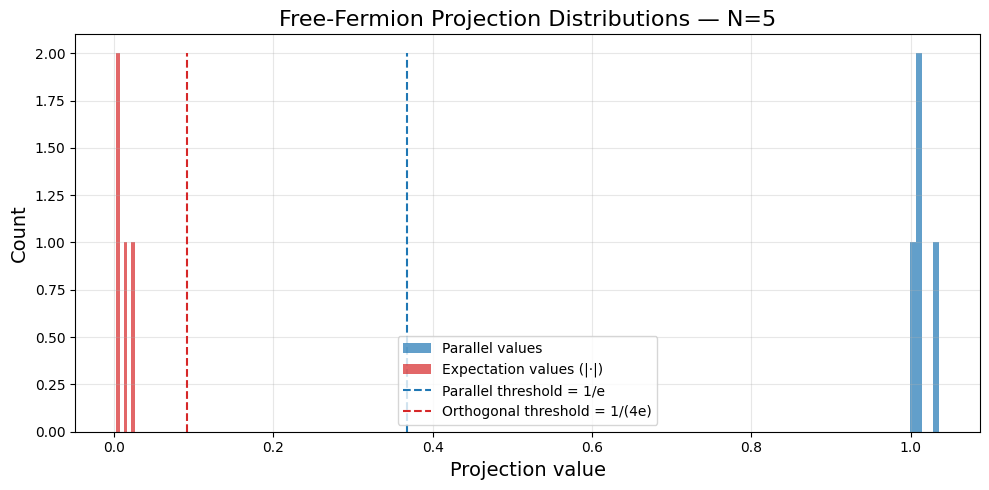

In [10]:
# Free-fermion Volume
evaluation = FreeFermion_benchmark.evaluate_benchmark()
FreeFermion_benchmark.plot_all_expectation_values()
FreeFermion_benchmark.plot_expectation_histograms(bins=5)

### Noisy simulator


In [4]:
# Define a circuit transformation that includes noise channels in the simulation


def add_twoq_depolarizing_noise(circuit, p2):
    noisy_circuit = cirq.Circuit()

    for moment in circuit:
        new_ops = []

        for op in moment.operations:
            new_ops.append(op)

            # Add 2-qubit depolarizing channel
            if len(op.qubits) == 2:
                new_ops.append(cirq.depolarize(p2, n_qubits=2).on(*op.qubits))

        noisy_circuit.append(new_ops)

    return noisy_circuit

In [5]:
# The workflow is the same as before
# Create benchmarks -> generate circuits -> execute circuits -> evaluate circuits
# Generate the benchmarks


In [6]:
# Generate the benchmarks

n_qubits = 5
sample_size = 1
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()


FreeFermion_benchmark = FreeFermionVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)

_ = FreeFermion_benchmark.create_benchmark()

In [7]:
# Convert the QASM strings to Cirq circuits

p2 = 0.01
circuits = Clifford_benchmark.get_all_circuits()  # Get all benchmark circuits
clifford_circuits = [
    add_twoq_depolarizing_noise(circuit_from_qasm(qasm_str), p2)
    for qasm_str in circuits
]  # Collect the Cirq circuits

# Convert the QASM strings to Cirq circuits

circuits = FreeFermion_benchmark.get_all_circuits()  # Get all benchmark circuits
freefermion_circuits = [
    add_twoq_depolarizing_noise(circuit_from_qasm(qasm_str), p2)
    for qasm_str in circuits
]  # Collect the Cirq circuits

In [8]:
# Create the ideal simulator

# simulator = cirq.Simulator()
simulator = qsimcirq.QSimSimulator()

In [9]:
# Execute the circuits

clifford_results = simulator.run_batch(
    programs=clifford_circuits,
    params_list=[{} for _ in clifford_circuits],
    repetitions=Clifford_benchmark.shots,
)

In [10]:
freefermion_results = simulator.run_batch(
    programs=freefermion_circuits,
    params_list=[{} for _ in freefermion_circuits],
    repetitions=FreeFermion_benchmark.shots,
)

In [11]:
# Get the counts from the measurement results
clifford_counts = []  # Store the counts for the Clifford Volume benchmark
for result in clifford_results:
    count = result[0].multi_measurement_histogram(
        keys=[f"c_{i}" for i in range(Clifford_benchmark.number_of_qubits)]
    )

    # Convert Cirq-style counts into the default bitstring-based count format
    counts_bitstring = {}
    for k in count.keys():
        bits = "".join([str(bit) for bit in k])

        counts_bitstring[bits] = count[k]

    clifford_counts.append(counts_bitstring)

In [12]:
# Get the counts from the measurement results
freefermion_counts = []  # Store the counts for the Free-Fermion Volume benchmark
for result in freefermion_results:
    count = result[0].multi_measurement_histogram(
        keys=[f"c_{i}" for i in range(FreeFermion_benchmark.number_of_qubits)]
    )

    # Convert Cirq-style counts into the default bitstring-based count format
    counts_bitstring = {}
    for k in count.keys():
        bits = "".join([str(bit) for bit in k])

        counts_bitstring[bits] = count[k]

    freefermion_counts.append(counts_bitstring)

In [13]:
# Attach the results

Clifford_benchmark.add_experimental_results(
    clifford_counts,
    experiment_id="cirq_clifford_demo",
    platform="cirq",
    experiment_metadata={"backend": "Cirq-simulator"},
)


FreeFermion_benchmark.add_experimental_results(
    freefermion_counts,
    experiment_id="cirq_freefermion_demo",
    platform="cirq",
    experiment_metadata={"backend": "Cirq-simulator"},
)


 Clifford Benchmark Evaluation (5 qubits)
Thresholds: τ_S = 1/e = 0.367879   τ_D = 1/(2e) = 0.183940
Shots per circuit: 1024
--------------------------------------------------------------
Stabilizers (all measured):
  • mean ± std: 0.880859 ± 0.041455
  • min EV:     0.822266
Destabilizers (all measured):
  • mean ± std: 0.001953 ± 0.026313
  • max |EV|:   0.035156
--------------------------------------------------------------
Per-sample pass count: 1/1
Worst stabilizer margin (min over samples of <S>-2σ): sample 0 -> 0.786697
Worst destabilizer margin (max over samples of |<D>|+2σ): sample 0 -> 0.097618
Benchmark passed (all samples): True



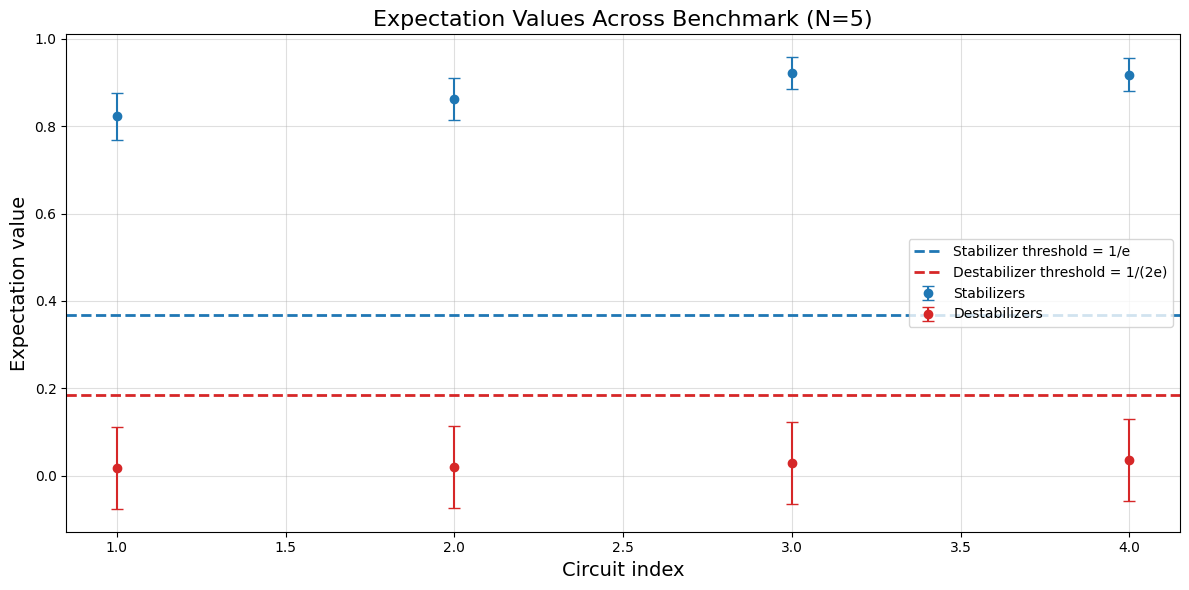

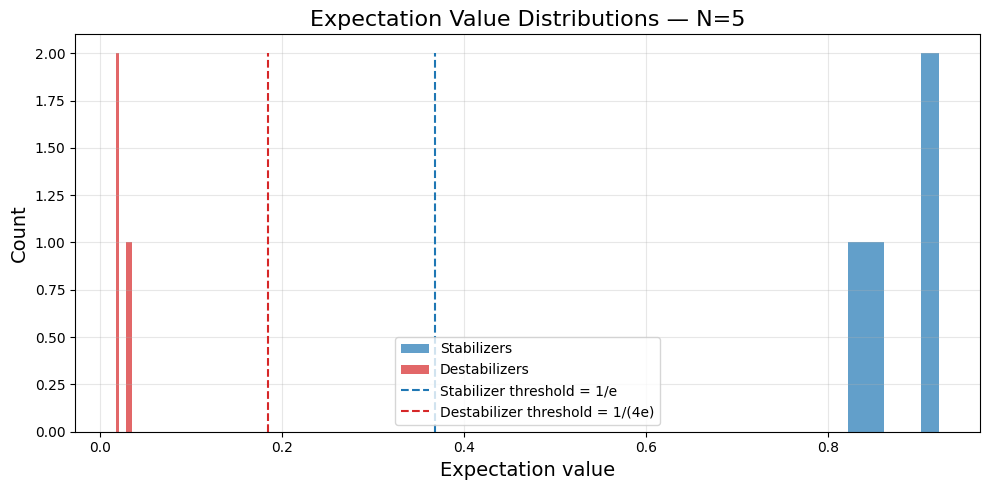

In [14]:
# Clifford Volume
evaluation = Clifford_benchmark.evaluate_benchmark()
Clifford_benchmark.plot_all_expectation_values()
Clifford_benchmark.plot_expectation_histograms(bins=5)


 Free-Fermion Benchmark Evaluation (5 qubits)

Parallel projected values (should be near 1):
  • average: 0.819914 ± 0.000000
  • lowest measured value: 0.819914

Orthogonal projected values (should be near 0):
  • average: 0.051646 ± 0.000000
  • highest absolute value: 0.051646


Benchmark passed: True



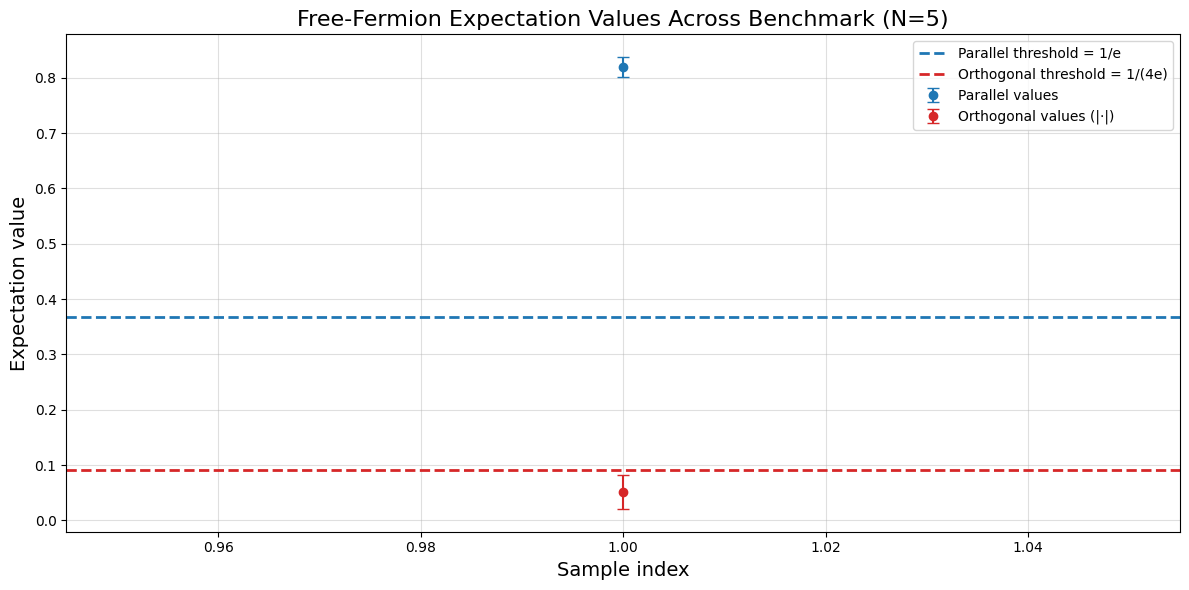

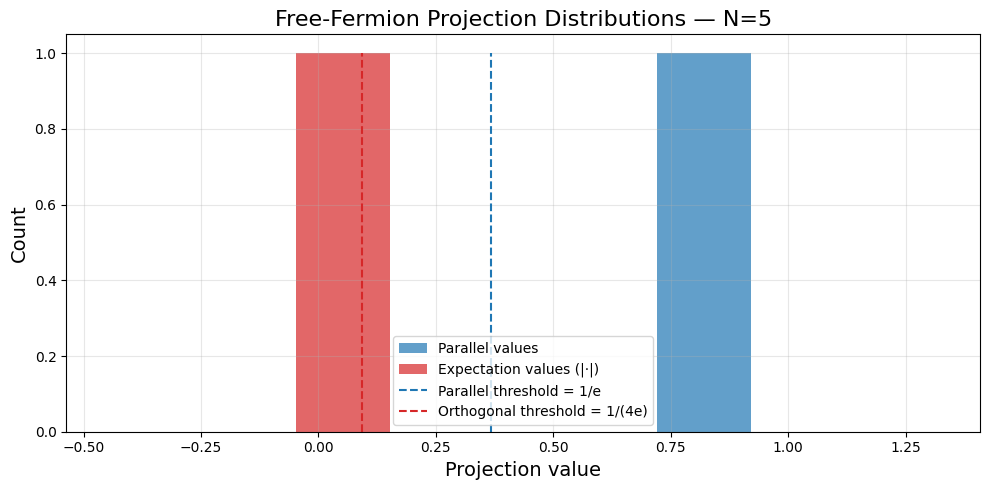

In [15]:
# Free-fermion Volume
evaluation = FreeFermion_benchmark.evaluate_benchmark()
FreeFermion_benchmark.plot_all_expectation_values()
FreeFermion_benchmark.plot_expectation_histograms(bins=5)

# Execute benchmarks on real hardware supporting Cirq


Until now, we used local simulators to execute our circuits. Cirq also supports running circuits on real quantum processors through Google's Quantum Engine API using the `cirq_google.Engine` interface.


You must have access to a Google Cloud project with permission to use a quantum processor.


In [16]:
project_id = "YOUR_PROJECT_ID"

engine = cg.Engine(project_id=project_id)

In [ ]:
# You can inspect the processors available to your account.
processors = [p.processor_id for p in engine.list_processors()]
print(processors)

In [ ]:
# Choose a processor
processor_id = processors[0]

processor = engine.get_processor(processor_id)
device = processor.get_device()
print(device)

For real hardware, we must transpile our benchmark circuit to a compatible gate set and map it to the qubits of the target device.


In [17]:
def map_to_device(circuit, device_qubits):
    logical = sorted(circuit.all_qubits())
    mapping = {q: device_qubits[i] for i, q in enumerate(logical)}
    return circuit.transform_qubits(lambda q: mapping[q])


def route_circuit(circuit, device):
    router = cirq.RouteCQC(device.metadata.nx_graph)
    routed = router(circuit)
    return routed


def compile_for_google(circuit):
    return cirq.optimize_for_target_gateset(
        circuit,
        gateset=cg.GoogleCZTargetGateset(),
    )

We can test our workflow without direct access to the hosted devices by using a locally simulated virtual backend.


In [18]:
engine = cg.engine.create_noiseless_virtual_engine_from_latest_templates()

In [19]:
for p in engine.list_processors():
    print(p.processor_id)

rainbow
weber
willow_pink


A circuit can be run in almost the same way as on real hardware.


In [20]:
processor_id = engine.list_processors()[0].processor_id
processor = engine.get_processor(processor_id)
sampler = engine.get_sampler(processor_id)

In [21]:
# Generate the benchmark

n_qubits = 5
sample_size = 4
shots = 1024

Clifford_benchmark = CliffordVolumeBenchmark(
    number_of_qubits=n_qubits,
    sample_size=sample_size,
    format="qasm2",
    target_sdk="cirq",
    shots=shots,
    auto_save=False,
)
_ = Clifford_benchmark.create_benchmark()

circuits = Clifford_benchmark.get_all_circuits()  # Get all benchmark circuits
clifford_circuits = [
    circuit_from_qasm(qasm_str) for qasm_str in circuits
]  # Collect the Cirq circuits

In [22]:
# Get device metadata for transpilation
device = processor.get_device()
hardware_qubits = sorted(device.metadata.qubit_set)


circuit = clifford_circuits[0]

# Transform the circuit so that it is compatible with the backend
hw_circuit = map_to_device(circuit, hardware_qubits)

hw_circuit = route_circuit(hw_circuit, device)

hw_circuit = compile_for_google(hw_circuit)

device.validate_circuit(hw_circuit)

# Execute the circuit; this can take several minutes
result = sampler.run(hw_circuit, repetitions=shots)

In [24]:
count = result.multi_measurement_histogram(
    keys=[f"c_{i}" for i in range(Clifford_benchmark.number_of_qubits)]
)

# Convert Cirq-style counts into the default bitstring-based count format
counts_bitstring = {}
for k in count.keys():
    bits = "".join([str(bit) for bit in k])

    counts_bitstring[bits] = count[k]


print(counts_bitstring)

{'01101': 59, '00110': 63, '10011': 68, '10010': 60, '01100': 64, '11001': 59, '01011': 68, '00111': 79, '00000': 64, '11110': 59, '00001': 72, '01010': 70, '10100': 55, '11000': 54, '11111': 54, '10101': 76}
